In [55]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print(" Libraries imported")

 Libraries imported


In [56]:
# Load data
df = pd.read_csv('marketing_dataset_sample.csv')

print(" Data loaded")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nColumns: {df.columns.tolist()}")

 Data loaded
Shape: (60, 15)

First 3 rows:
        Week     FB_Spend     GG_Spend  Seasonality  Promo    FB_Adstock  \
0   1/7/2024  4247.240713  5720.741028     1.000000      1   4247.240713   
1  1/14/2024  7704.285838  4899.443222     1.031813      1   9827.906195   
2  1/21/2024  6391.963651  8801.162564     1.062815      0  11305.916750   

     GG_Adstock  FB_Effect  GG_Effect      Traffic       Sales       Clicks  \
0   5720.741028   0.419132   0.566926  2882.392277  356.442465  2882.392277   
1   6615.665531   0.794387   0.636454  3933.723103  432.305673  3933.723103   
2  10785.862220   0.836413   0.823115  4804.874393  426.433121  4804.874393   

   Conversions       CPC        CR  
0   356.442465  3.683781  0.123662  
1   432.305673  4.896307  0.109897  
2   426.433121  3.325770  0.088750  

Columns: ['Week', 'FB_Spend', 'GG_Spend', 'Seasonality', 'Promo', 'FB_Adstock', 'GG_Adstock', 'FB_Effect', 'GG_Effect', 'Traffic', 'Sales', 'Clicks', 'Conversions', 'CPC', 'CR']


CORRELATION WITH SALES
 Sales: 1.0000 (target)
   Traffic: 0.4641 →  Medium
   GG_Spend: 0.4026 →  Medium
   Promo: 0.3940 →  Medium
   Seasonality: 0.3512 →  Medium
   FB_Spend: 0.1944 →  Weak

FULL CORRELATION MATRIX
             FB_Spend  GG_Spend  Traffic  Sales  Promo  Seasonality
FB_Spend        1.000    -0.008    0.280  0.194  0.017        0.110
GG_Spend       -0.008     1.000    0.753  0.403 -0.120       -0.021
Traffic         0.280     0.753    1.000  0.464 -0.251       -0.022
Sales           0.194     0.403    0.464  1.000  0.394        0.351
Promo           0.017    -0.120   -0.251  0.394  1.000       -0.059
Seasonality     0.110    -0.021   -0.022  0.351 -0.059        1.000


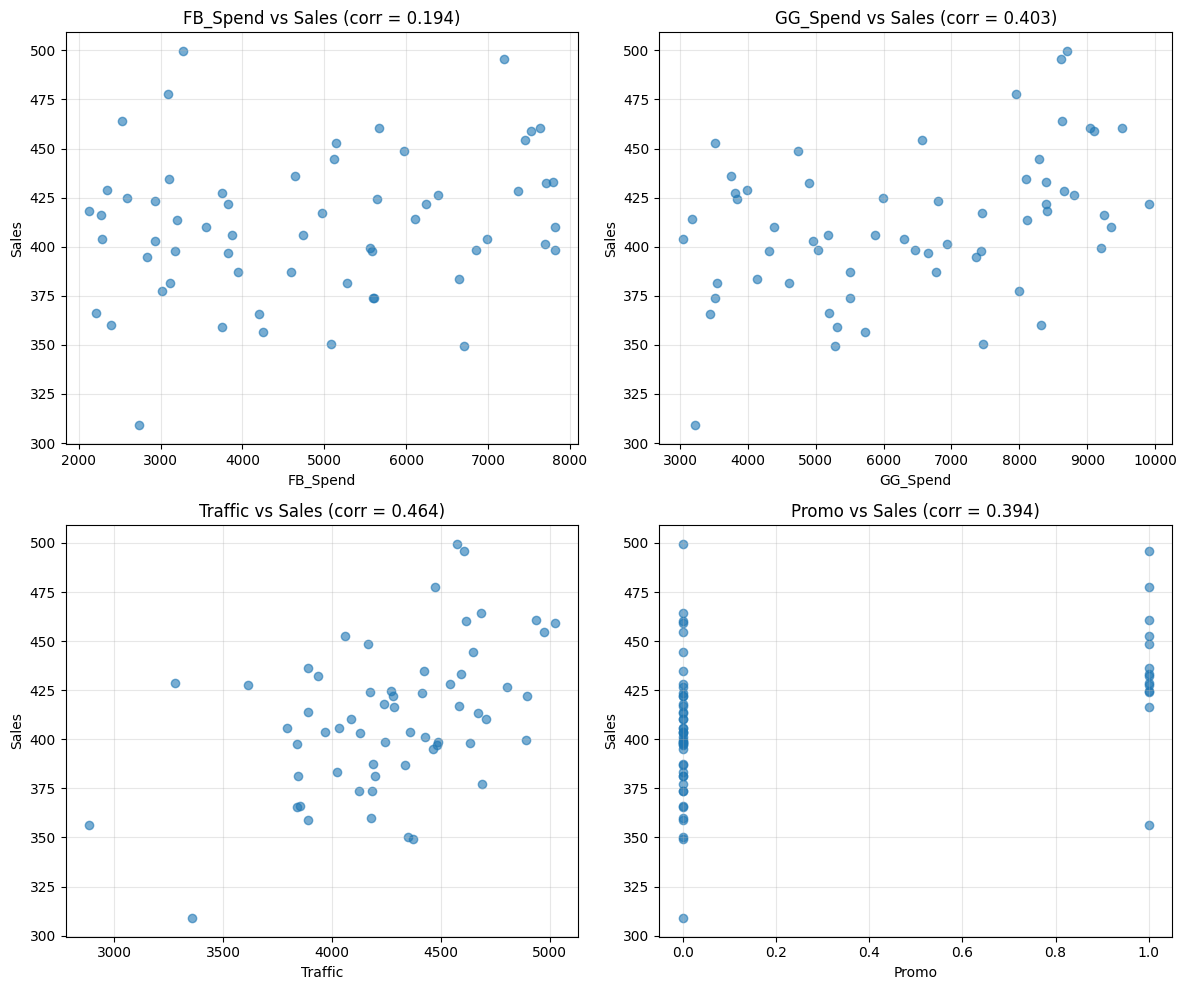


Conclusion
 It is recommended to use the following in the model: Variables with a correlation greater than 0.3 with Sales
 Variables with a correlation of less than 0.3 with Sales should not be used.


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('marketing_dataset_sample.csv')

numeric_cols = ['FB_Spend', 'GG_Spend', 'Traffic', 'Sales', 'Promo', 'Seasonality']
df_numeric = df[numeric_cols]

correlations = df_numeric.corr()['Sales'].sort_values(ascending=False)

print("="*50)
print("CORRELATION WITH SALES")
print("="*50)
for col, corr in correlations.items():
    if col == 'Sales':
        print(f" {col}: {corr:.4f} (target)")
    else:
        # Đánh giá mức độ
        if abs(corr) > 0.7:
            level = " Very strong"
        elif abs(corr) > 0.5:
            level = " Strong"
        elif abs(corr) > 0.3:
            level = " Medium"
        elif abs(corr) > 0.1:
            level = " Weak"
        else:
            level = " Very weak / Null"
        
        print(f"   {col}: {corr:.4f} → {level}")

print("\n" + "="*50)
print("FULL CORRELATION MATRIX")
print("="*50)
print(df_numeric.corr().round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter: FB_Spend vs Sales
axes[0, 0].scatter(df['FB_Spend'], df['Sales'], alpha=0.6)
axes[0, 0].set_xlabel('FB_Spend')
axes[0, 0].set_ylabel('Sales')
axes[0, 0].set_title(f'FB_Spend vs Sales (corr = {correlations["FB_Spend"]:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# Scatter: GG_Spend vs Sales
axes[0, 1].scatter(df['GG_Spend'], df['Sales'], alpha=0.6)
axes[0, 1].set_xlabel('GG_Spend')
axes[0, 1].set_ylabel('Sales')
axes[0, 1].set_title(f'GG_Spend vs Sales (corr = {correlations["GG_Spend"]:.3f})')
axes[0, 1].grid(True, alpha=0.3)

# Scatter: Traffic vs Sales
axes[1, 0].scatter(df['Traffic'], df['Sales'], alpha=0.6)
axes[1, 0].set_xlabel('Traffic')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].set_title(f'Traffic vs Sales (corr = {correlations["Traffic"]:.3f})')
axes[1, 0].grid(True, alpha=0.3)

# Scatter: Promo vs Sales
axes[1, 1].scatter(df['Promo'], df['Sales'], alpha=0.6)
axes[1, 1].set_xlabel('Promo')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].set_title(f'Promo vs Sales (corr = {correlations["Promo"]:.3f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Conclusion")
print("="*50)
print(" It is recommended to use the following in the model: Variables with a correlation greater than 0.3 with Sales")
print(" Variables with a correlation of less than 0.3 with Sales should not be used.")

traffic_corr = correlations['Traffic']
if abs(traffic_corr) < 0.3:
    print(f"\n Traffic has a correlation = {traffic_corr:.3f} with Sales (< 0.3)")
    print(" → This is why the two-tier model (Spend→Traffic→Sales) is wrong!")

In [58]:
class SimpleMarketingModel:
    
    def __init__(self, alpha=1.0):
        self.model = Ridge(alpha=alpha)
        self.coefficients = {}
    
    def fit(self, df, spend_cols, promo_col, season_col, sales_col):
        X = df[spend_cols + [promo_col, season_col]].values
        y = df[sales_col].values
        
        self.model.fit(X, y)
        
        all_cols = spend_cols + [promo_col, season_col]
        self.coefficients = dict(zip(all_cols, self.model.coef_))
        
        print("\n MODEL COEFFICIENTS")
        print("-" * 40)
        for col, coef in self.coefficients.items():
            print(f"   {col}: {coef:.4f}")
        print(f"   Intercept: {self.model.intercept_:.1f}")
        
        return self
    
    def predict(self, df, spend_cols, promo_col, season_col):
        X = df[spend_cols + [promo_col, season_col]].values
        return self.model.predict(X)
    
    def evaluate(self, y_true, y_pred):
        r2 = r2_score(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        return {'R2': r2, 'MAPE': mape}

print(" SimpleMarketingModel class defined")

 SimpleMarketingModel class defined


In [59]:
model = SimpleMarketingModel(alpha=0.5)

spend_cols = ['FB_Spend', 'GG_Spend']

model.fit(df, spend_cols, 'Promo', 'Seasonality', 'Sales')

print("\n Training completed")


 MODEL COEFFICIENTS
----------------------------------------
   FB_Spend: 0.0033
   GG_Spend: 0.0083
   Promo: 37.8856
   Seasonality: 68.4098
   Intercept: 262.0

 Training completed


In [60]:
## Prediction
sales_pred = model.predict(df, spend_cols, 'Promo', 'Seasonality')

# Evaluation
metrics = model.evaluate(df['Sales'].values, sales_pred)

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f" R² Score: {metrics['R2']:.4f}")
print(f" MAPE: {metrics['MAPE']:.2f}%")

# Nhận xét
if metrics['R2'] > 0.7:
    print("    Excellent model!")
elif metrics['R2'] > 0.5:
    print("    Good model")
elif metrics['R2'] > 0.3:
    print("    Acceptable model")
else:
    print("    Model needs improvement")


MODEL EVALUATION
 R² Score: 0.5188
 MAPE: 4.75%
    Good model


In [61]:
comparison = pd.DataFrame({
    'Week': df['Week'],
    'Actual_Sales': df['Sales'],
    'Predicted_Sales': sales_pred,
    'Error': df['Sales'] - sales_pred,
    'Error_Pct': abs((df['Sales'] - sales_pred) / df['Sales'] * 100)
})

print("\n First 10 weeks comparison:")
print(comparison.head(10))

print(f"\n Summary:")
print(f"   Mean Error: {comparison['Error'].mean():.1f}")
print(f"   Mean Absolute Error: {comparison['Error'].abs().mean():.1f}")
print(f"   Mean Error %: {comparison['Error_Pct'].mean():.1f}%")


 First 10 weeks comparison:
        Week  Actual_Sales  Predicted_Sales      Error  Error_Pct
0   1/7/2024    356.442465       429.505269 -73.062804  20.497783
1  1/14/2024    432.305673       436.139702  -3.834029   0.886879
2  1/21/2024    426.433121       428.401682  -1.968561   0.461634
3  1/28/2024    373.670872       400.457096 -26.786224   7.168400
4   2/4/2024    403.102008       389.266093  13.835915   3.432361
5  2/11/2024    423.376337       406.077476  17.298861   4.085930
6  2/18/2024    428.775787       420.161366   8.614421   2.009074
7  2/25/2024    495.678448       475.378118  20.300331   4.095464
8   3/3/2024    373.875725       390.942513 -17.066788   4.564829
9  3/10/2024    421.802619       446.362622 -24.560003   5.822629

 Summary:
   Mean Error: 0.0
   Mean Absolute Error: 19.1
   Mean Error %: 4.8%


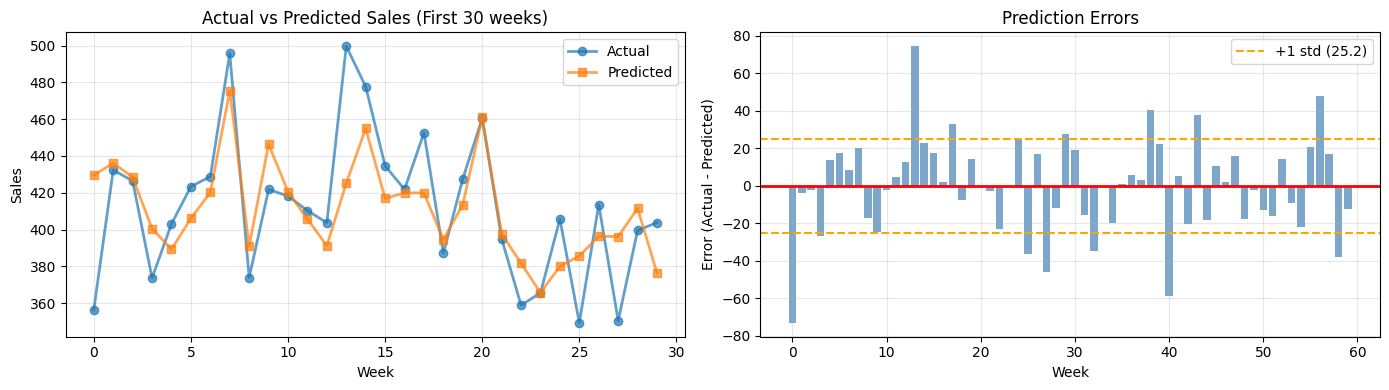

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

n_weeks = len(df)
weeks_to_plot = min(30, n_weeks)  

# Chart 1: Actual vs Predicted
axes[0].plot(range(weeks_to_plot), df['Sales'].values[:weeks_to_plot], 'o-', label='Actual', alpha=0.7, linewidth=2)
axes[0].plot(range(weeks_to_plot), sales_pred[:weeks_to_plot], 's-', label='Predicted', alpha=0.7, linewidth=2)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Sales')
axes[0].set_title(f'Actual vs Predicted Sales (First {weeks_to_plot} weeks)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Residuals (Error)
errors = df['Sales'].values - sales_pred
axes[1].bar(range(len(errors)), errors, alpha=0.7, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='-', linewidth=2)
axes[1].axhline(y=errors.std(), color='orange', linestyle='--', label=f'+1 std ({errors.std():.1f})')
axes[1].axhline(y=-errors.std(), color='orange', linestyle='--')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Error (Actual - Predicted)')
axes[1].set_title('Prediction Errors')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
print(" Coefficients before saving:")
for col, coef in model.coefficients.items():
    print(f"   {col}: {coef:.6f}")

joblib.dump(model, 'marketing_model_simple.pkl')
print("\n Model saved to 'marketing_model_simple.pkl'")

model_check = joblib.load('marketing_model_simple.pkl')
print("\n Verification - reloaded model coefficients:")
for col, coef in model_check.coefficients.items():
    print(f"   {col}: {coef:.6f}")

 Coefficients before saving:
   FB_Spend: 0.003256
   GG_Spend: 0.008278
   Promo: 37.885641
   Seasonality: 68.409769

 Model saved to 'marketing_model_simple.pkl'

 Verification - reloaded model coefficients:
   FB_Spend: 0.003256
   GG_Spend: 0.008278
   Promo: 37.885641
   Seasonality: 68.409769
